# 📊 BƯỚC 1: Khai Phá Dữ Liệu (EDA) - Tìm Kiếm Insight

Notebook này tập trung vào việc phân tích dữ liệu lớn mà **KHÔNG GÂY TRÀN RAM (OOM)** bằng cách sử dụng `PyArrow` để tính toán từng phần hoặc lọc dữ liệu (push-down predicates).

### Mục tiêu:
1. Phân tích phân phối của `event_type`.
2. Thống kê tỷ lệ chuyển đổi (Từ View -> Contact).
3. Thống kê theo ngày (Daily Trends) để xác định tính thời vụ (Time-decay).

In [1]:
import os
import sys
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BUCKET_NAME = "datathon_2026_final"
TRAIN_PATH = f"gs://{BUCKET_NAME}/train/"
TEST_PATH = f"gs://{BUCKET_NAME}/test/"

# Thiết lập đồ thị
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

### 1. Phân tích Các Loại Sự Kiện (Event Types)
Quét nhanh toàn bộ tập `fact_user_events` để đếm số lượng mỗi loại sự kiện.

Đang quét dữ liệu (có thể mất vài phút cho 160GB data)...

--- TỔNG HỢP SỐ LƯỢNG EVENT ---


,Event_Type,Count
0,other_interaction,90673318
1,pageview,65548923
2,view_phone,4062168
3,contact_chat,1085838
4,contact_zalo,231926
5,contact_sms,129163


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 43

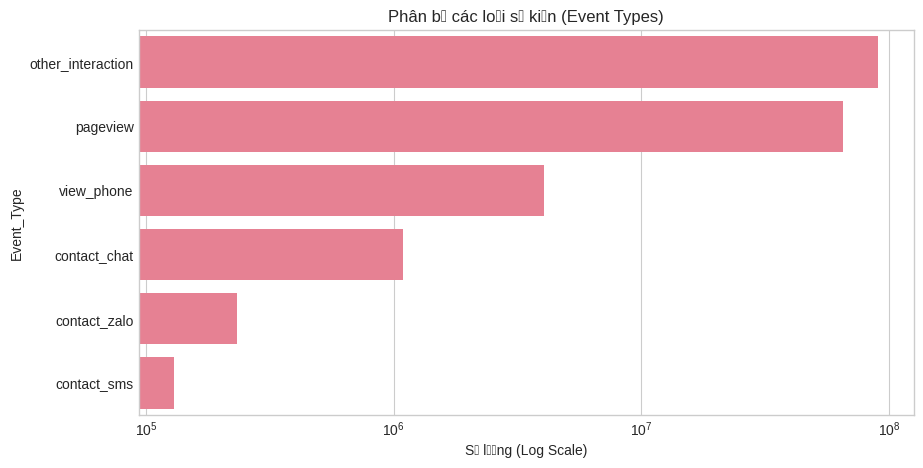

In [ ]:
folder_path = f"{TRAIN_PATH}fact_user_events/"
dataset = ds.dataset(folder_path, format="parquet")

# Để tránh OOM, chúng ta sẽ đếm tổng số lượng sự kiện bằng cách quét qua từng batch (chunking)
event_counts = {}

print("Đang quét dữ liệu (có thể mất vài phút cho 160GB data)...")
for batch in dataset.to_batches(columns=["event_type"]):
    # Chuyển batch (PyArrow) sang pandas để đếm nhanh
    counts = batch.to_pandas()["event_type"].value_counts()
    for event, count in counts.items():
        event_counts[event] = event_counts.get(event, 0) + count

df_events = pd.DataFrame(list(event_counts.items()), columns=["Event_Type", "Count"])
df_events = df_events.sort_values(by="Count", ascending=False)

print("\n--- TỔNG HỢP SỐ LƯỢNG EVENT ---")
display(df_events)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(data=df_events, x="Count", y="Event_Type")
plt.title("Phân bố các loại sự kiện (Event Types)")
plt.xscale('log') # Dùng log scale vì sự kiện view chắc chắn áp đảo contact
plt.xlabel("Số lượng (Log Scale)")
plt.show()

### 2. Phân tích Bất Động Sản (Listings)
Đọc tập `dim_listing` để xem phân phối giá, khu vực.

Tổng số lượng tin đăng (listings): 3,107,114


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7891 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7861 (\N{LATIN SMALL LETTER A WITH BREVE AND TILDE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 417 (\N{LAT

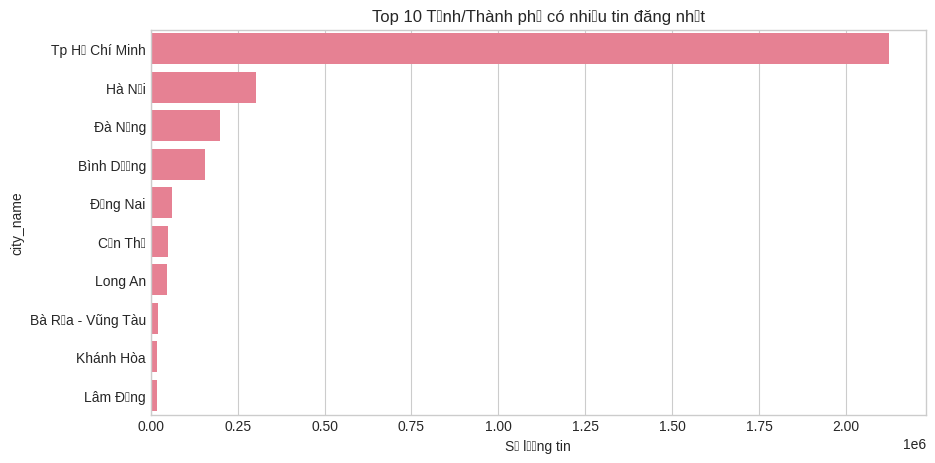

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 

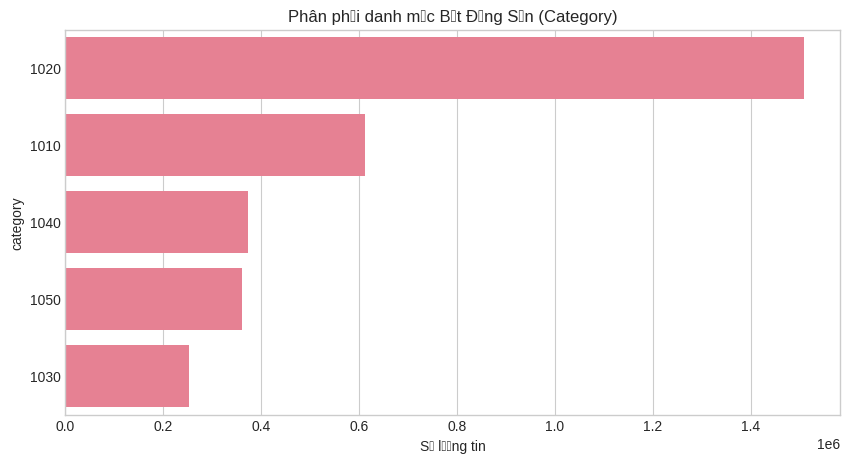

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7893 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyp

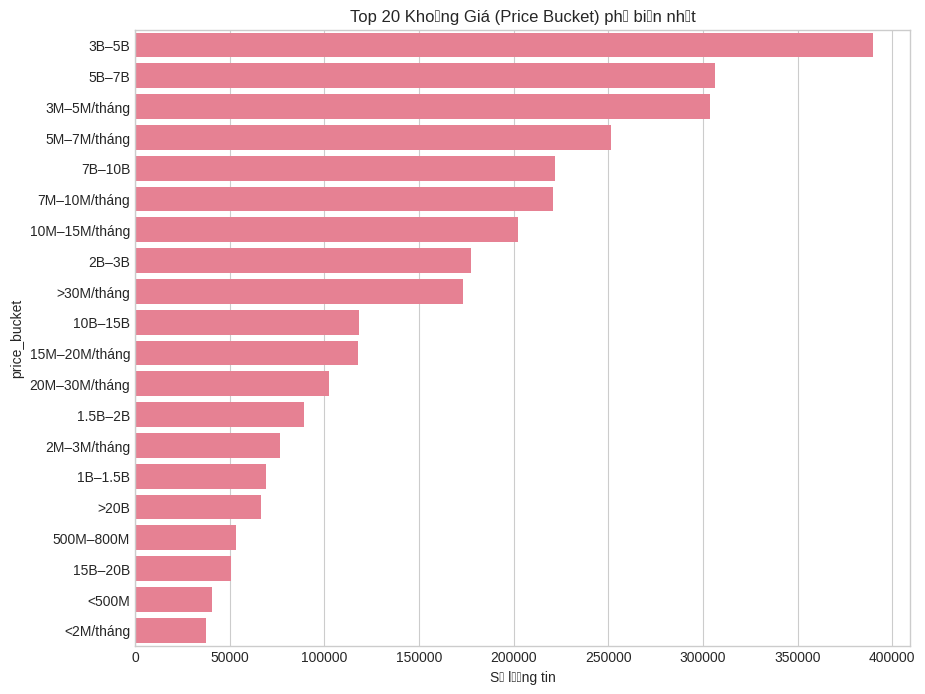

In [ ]:
# File dim_listing là một thư mục chứa 40 files, ta dùng pyarrow dataset để đọc
dataset_listing = ds.dataset(f"{TRAIN_PATH}dim_listing/", format="parquet")
df_listing = dataset_listing.to_table().to_pandas()
print(f"Tổng số lượng tin đăng (listings): {len(df_listing):,}")

# Thống kê top 10 Tỉnh/Thành phố có nhiều tin đăng nhất
top_cities = df_listing['city_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Tỉnh/Thành phố có nhiều tin đăng nhất")
plt.xlabel("Số lượng tin")
plt.show()

# Phân phối loại danh mục (category)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_listing, y='category', order=df_listing['category'].value_counts().index)
plt.title("Phân phối danh mục Bất Động Sản (Category)")
plt.xlabel("Số lượng tin")
plt.show()

# Phân phối price_bucket (Khoảng giá)
plt.figure(figsize=(10, 8))
top_price_buckets = df_listing['price_bucket'].value_counts().head(20).index
sns.countplot(data=df_listing[df_listing['price_bucket'].isin(top_price_buckets)], y='price_bucket', order=top_price_buckets)
plt.title("Top 20 Khoảng Giá (Price Bucket) phổ biến nhất")
plt.xlabel("Số lượng tin")
plt.show()


### 3. Phân tích tương tác Positive (Chỉ lấy Contact/View Phone)
Hiểu được xu hướng User tương tác tích cực theo thời gian.

Đang lọc các sự kiện Tương tác tích cực (Positive Events)...


/tmp/ipykernel_9418/3565599730.py:21: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9418/3565599730.py:21: UserWarning: Glyph 7899 (\N{LATIN SMALL LETTER O WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9418/3565599730.py:21: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_9418/3565599730.py:21: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7899 (\N{LATIN SMALL LETTER O WITH HORN AND

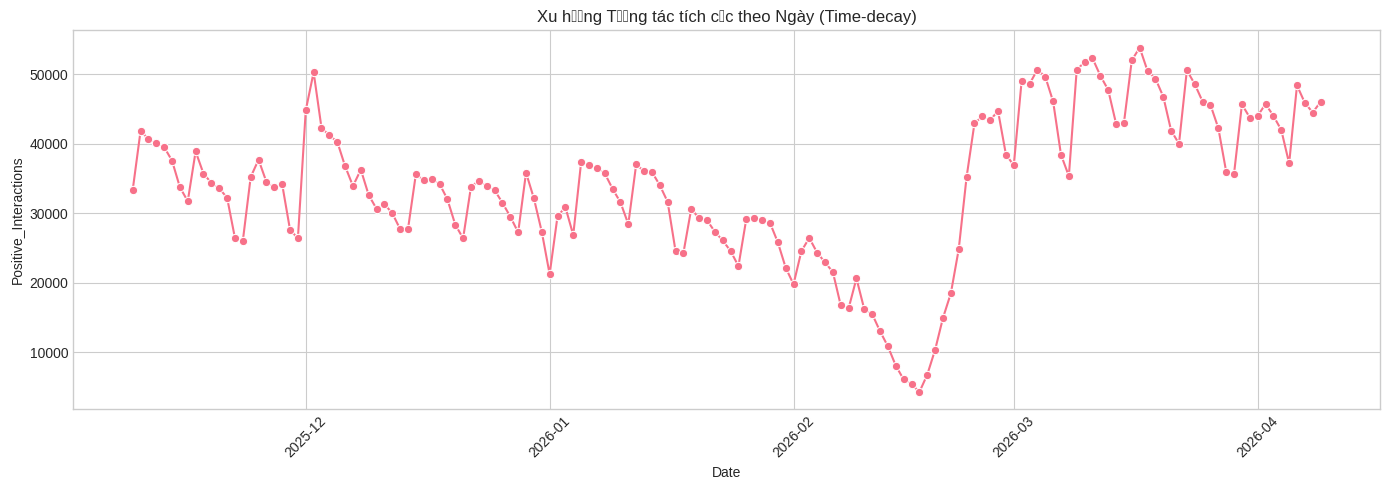

Insights: Nếu có xu hướng giảm dần ở cuối (gần ngày cut-off 09/04/2026), model cần trọng số thời gian (Time-decay).


In [ ]:
# Chỉ quét và lấy các dòng có event_type là contact_chat hoặc view_phone
positive_condition = pc.field("event_type").isin(["contact_chat", "view_phone"])

positive_dates = {}
print("Đang lọc các sự kiện Tương tác tích cực (Positive Events)...")

for batch in dataset.to_batches(columns=["event_type", "date"], filter=positive_condition):
    df_batch = batch.to_pandas()
    counts = df_batch['date'].value_counts()
    for date_val, count in counts.items():
        positive_dates[date_val] = positive_dates.get(date_val, 0) + count

df_daily_pos = pd.DataFrame(list(positive_dates.items()), columns=["Date", "Positive_Interactions"])
df_daily_pos["Date"] = pd.to_datetime(df_daily_pos["Date"])
df_daily_pos = df_daily_pos.sort_values(by="Date")

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_daily_pos, x="Date", y="Positive_Interactions", marker='o')
plt.title("Xu hướng Tương tác tích cực theo Ngày (Time-decay)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Insights: Nếu có xu hướng giảm dần ở cuối (gần ngày cut-off 09/04/2026), model cần trọng số thời gian (Time-decay).")